In [ ]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 534.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.9 MB/s eta 0:00:00


In [ ]:
from PIL import Image
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from keras.applications import vgg16, resnet
from keras.preprocessing.image import load_img,img_to_array
from keras.models import Model
from keras.applications.imagenet_utils import preprocess_input
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
imgs_path = "/content/drive/MyDrive/archive/fashion-dataset/fashion-dataset/images"
imgs_model_width, imgs_model_height = 224, 224

In [ ]:
files = [imgs_path + x for x in os.listdir(imgs_path) if "jpg" in x]
print("Total number of images:", len(files))

Total number of images: 2457


# EDA и визуализация

In [ ]:
styles = pd.read_csv(
    "/content/drive/MyDrive/archive/fashion-dataset/styles.csv",
    on_bad_lines='warn')

<ipython-input-6-947387df1da4>:1: ParserWarning: Skipping line 6044: expected 10 fields, saw 11
Skipping line 6569: expected 10 fields, saw 11
Skipping line 7399: expected 10 fields, saw 11
Skipping line 7939: expected 10 fields, saw 11
Skipping line 9026: expected 10 fields, saw 11
Skipping line 10264: expected 10 fields, saw 11
Skipping line 10427: expected 10 fields, saw 11
Skipping line 10905: expected 10 fields, saw 11
Skipping line 11373: expected 10 fields, saw 11
Skipping line 11945: expected 10 fields, saw 11
Skipping line 14112: expected 10 fields, saw 11
Skipping line 14532: expected 10 fields, saw 11
Skipping line 15076: expected 10 fields, saw 12
Skipping line 29906: expected 10 fields, saw 11
Skipping line 31625: expected 10 fields, saw 11
Skipping line 33020: expected 10 fields, saw 11
Skipping line 35748: expected 10 fields, saw 11
Skipping line 35962: expected 10 fields, saw 11
Skipping line 37770: expected 10 fields, saw 11
Skipping line 38105: expected 10 fields, saw

In [ ]:
styles.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


# Товары для мужчин vs товары для женщин

In [ ]:
fig = px.pie(styles, styles['gender'], color_discrete_sequence=px.colors.sequential.RdBu)
fig.update_layout(title="Распределение товаров", width=800, height=800, font=dict(family="Segoe UI semilight", size=16))
fig.show()

In [ ]:
catcounts=(styles['masterCategory']).value_counts()

# Наиболее популярные категории

In [ ]:
fig = go.Figure([go.Bar(x=catcounts.index, y=catcounts.values, text=catcounts.values, marker_color='darkkhaki')])
fig.update_traces(texttemplate='%{text:.2s}', textposition='outside')
fig.update_layout(title="Топ категории", width=1000, height=900, xaxis_title='Категория',
                  yaxis_title='Количество покупок', font=dict(family="Segoe UI semilight", size=16))
fig.show()

Большей популярностью пользуется одежда.

# High season покупок

In [ ]:
seasons=(styles['season']).value_counts()

In [ ]:
fig = go.Figure(data=[go.Scatter(x=seasons.index, y=seasons.values, mode='markers',
    marker=dict(color=['rgb(93, 164, 214)', 'rgb(255, 144, 14)', 'rgb(44, 160, 101)', 'rgb(255, 65, 54)'],
                opacity=[0.6, 0.7, 0.8, 1], size=[123, 65, 49, 17]))])
fig.update_layout(width=900, height=900, title="Зависимость количества покупок от времени года", xaxis_title='Сезон', yaxis_title='Количество',
                  font=dict(family="Segoe UI semilight", size=16))
fig.show()

3/4 товаров покупаются летом и осенью.

# Наиболее популярные типы товаров

In [ ]:
articles = pd.value_counts(styles['articleType'])
fig = go.Figure([go.Bar(x=articles.index[:15], y=articles.values[:15], text=articles.values[:15], marker_color='darkmagenta')])
fig.update_traces(texttemplate='%{text:.2s}', textposition='outside')
fig.update_layout(title="Топ 15 категорий", xaxis_title='Категория', yaxis_title='Количество покупок',
                  width=950, height=750, font=dict(family="Segoe UI semilight", size=16))
fig.show()

<ipython-input-13-2b78efcdc7fc>:1: FutureWarning:

pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.



Футболки и рубашки - лидеры продаж. Очевидно, это наиболее подходящая одежда для лета и осени в регионе.

# Извлечение признаков одного изображения

Для сокращения времени выполнения алгоритма сократим данные до 4000 изображений для предотвращения остановки ядра

In [ ]:
files=files[0:4001]

In [ ]:
# Исправляем все пути в списке files
files = [f.replace('images', 'images/') if 'images' in f else f for f in files]

print(files[432])
original = load_img(files[432], target_size=(imgs_model_width, imgs_model_height))

/content/drive/MyDrive/archive/fashion-dataset/fashion-dataset/images/12213.jpg


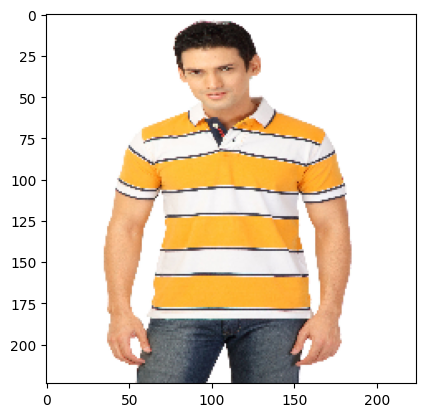

Пример данных


In [ ]:
original = load_img(files[433], target_size=(imgs_model_width, imgs_model_height))
plt.imshow(original)
plt.show()
print("Пример данных")

# Первый метод: VGG + косинусное расстояние

На вход сети будут подаваться 3-х канальные изображения 224х224

In [ ]:
vgg_model = vgg16.VGG16(weights='imagenet');
feat_extractor = Model(inputs=vgg_model.input, outputs=vgg_model.get_layer("fc2").output);
feat_extractor.summary()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,260,544 (512.16 MB)

 Trainable params: 134,260,544 (512.16 MB)

 Non-trainable params: 0 (0.00 B)

С помощью **preprocess_input** изображения преобразуются из RGB в BGR, затем каждый цветовой канал центрируется по отношению к набору данных ImageNet без масштабирования.

In [ ]:
numpy_image = img_to_array(original)
# преобразуем изображение в массив
# добавим одно измерение
# входные данные должны иметь вид (batchsize, height, width, channels)
image_batch = np.expand_dims(numpy_image, axis=0)
print('Размерность входных данных', image_batch.shape)
processed_image = preprocess_input(image_batch.copy())

Размерность входных данных (1, 224, 224, 3)


In [ ]:
img_features = feat_extractor.predict(processed_image)
print("Извлечены признаки одного изображения")
print("Количество признаков:", img_features.size)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1000ms/step
Извлечены признаки одного изображения
Количество признаков: 4096


# Проделаем те же действия с множеством изображений

In [ ]:
importedImages = []
for f in files:
    filename = f
    original = load_img(filename, target_size=(224, 224))
    numpy_image = img_to_array(original)
    image_batch = np.expand_dims(numpy_image, axis=0)
    importedImages.append(image_batch)
images = np.vstack(importedImages)
processed_imgs = preprocess_input(images.copy())

In [ ]:
imgs_features = feat_extractor.predict(processed_imgs)
print("Признаки извлечены")
imgs_features.shape

77/77 ━━━━━━━━━━━━━━━━━━━━ 573s 7s/step
Признаки извлечены


(2457, 4096)

In [ ]:
print("Извлечено", imgs_features.shape[0], "признаков для каждого из", imgs_features.shape[1], "изображений.")

Извлечено 2457 признаков для каждого из 4096 изображений.


Подбор релевантных товаров осуществим на основе косинусного подобия - нормализованное скалярное произведение X и Y.

In [ ]:
cosSimilarities = cosine_similarity(imgs_features)
# загрузим матрицу релевантности товаров в pandas df
cos_similarities_df = pd.DataFrame(cosSimilarities, columns=files, index=files)
cos_similarities_df.head()

,/content/drive/MyDrive/archive/fashion-dataset/fashion-dataset/images/11731.jpg,/content/drive/MyDrive/archive/fashion-dataset/fashion-dataset/images/11778.jpg,/content/drive/MyDrive/archive/fashion-dataset/fashion-dataset/images/11693.jpg,/content/drive/MyDrive/archive/fashion-dataset/fashion-dataset/images/11735.jpg,/content/drive/MyDrive/archive/fashion-dataset/fashion-dataset/images/11786.jpg,/content/drive/MyDrive/archive/fashion-dataset/fashion-dataset/images/11714.jpg,/content/drive/MyDrive/archive/fashion-dataset/fashion-dataset/images/11793.jpg,/content/drive/MyDrive/archive/fashion-dataset/fashion-dataset/images/11717.jpg,/content/drive/MyDrive/archive/fashion-dataset/fashion-dataset/images/11711.jpg,/content/drive/MyDrive/archive/fashion-dataset/fashion-dataset/images/11719.jpg,...,/content/drive/MyDrive/archive/fashion-dataset/fashion-dataset/images/10585.jpg,/content/drive/MyDrive/archive/fashion-dataset/fashion-dataset/images/10443.jpg,/content/drive/MyDrive/archive/fashion-dataset/fashion-dataset/images/10567.jpg,/content/drive/MyDrive/archive/fashion-dataset/fashion-dataset/images/10571.jpg,/content/drive/MyDrive/archive/fashion-dataset/fashion-dataset/images/10487.jpg,/content/drive/MyDrive/archive/fashion-dataset/fashion-dataset/images/10498.jpg,/content/drive/MyDrive/archive/fashion-dataset/fashion-dataset/images/10582.jpg,/content/drive/MyDrive/archive/fashion-dataset/fashion-dataset/images/10503.jpg,/content/drive/MyDrive/archive/fashion-dataset/fashion-dataset/images/10572.jpg,/content/drive/MyDrive/archive/fashion-dataset/fashion-dataset/images/10474.jpg
/content/drive/MyDrive/archive/fashion-dataset/fashion-dataset/images/11731.jpg,1.000000,0.700691,0.694337,0.739968,0.570280,0.685320,0.562904,0.776112,0.701538,0.749218,...,0.186062,0.703723,0.725406,0.762457,0.505909,0.503866,0.149037,0.746940,0.579633,0.698065
/content/drive/MyDrive/archive/fashion-dataset/fashion-dataset/images/11778.jpg,0.700691,1.000000,0.687848,0.789752,0.587993,0.788773,0.570672,0.651630,0.879164,0.800266,...,0.158072,0.701719,0.660310,0.784094,0.671208,0.557470,0.120879,0.704347,0.753096,0.639270
/content/drive/MyDrive/archive/fashion-dataset/fashion-dataset/images/11693.jpg,0.694337,0.687848,1.000000,0.748078,0.659655,0.775013,0.635286,0.763802,0.760304,0.887366,...,0.174774,0.741572,0.711418,0.755154,0.507198,0.603421,0.139034,0.670565,0.693065,0.861081
/content/drive/MyDrive/archive/fashion-dataset/fashion-dataset/images/11735.jpg,0.739968,0.789752,0.748078,1.000000,0.635687,0.769406,0.621792,0.719943,0.804349,0.834692,...,0.197956,0.830439,0.765314,0.877467,0.581521,0.569942,0.169867,0.736728,0.644588,0.735923
/content/drive/MyDrive/archive/fashion-dataset/fashion-dataset/images/11786.jpg,0.570280,0.587993,0.659655,0.635687,1.000000,0.723511,0.807971,0.564802,0.584542,0.651125,...,0.169430,0.564404,0.773737,0.716854,0.403846,0.715024,0.162791,0.711895,0.511574,0.604085


In [ ]:
# функция подбора 4 релевантных товаров на основе выбранного
nb_closest_images = 4
def retrieve_relevant_products(given_img):
    print("     Выбранный товар")
    original = load_img(given_img, target_size=(imgs_model_width, imgs_model_height))
    plt.imshow(original)
    plt.show()
    print("    _____________________________")
    print("    Релевантные товары")
    closest_imgs = cos_similarities_df[given_img].sort_values(ascending=False)[1:nb_closest_images+1].index
    closest_imgs_scores = 100*cos_similarities_df[given_img].sort_values(ascending=False)[1:nb_closest_images+1]
    for i in range(0,len(closest_imgs)):
        original = load_img(closest_imgs[i], target_size=(imgs_model_width, imgs_model_height))
        plt.imshow(original)
        plt.show()
        print("     Схожесть: ", round(closest_imgs_scores[i],2), "%")

     Выбранный товар


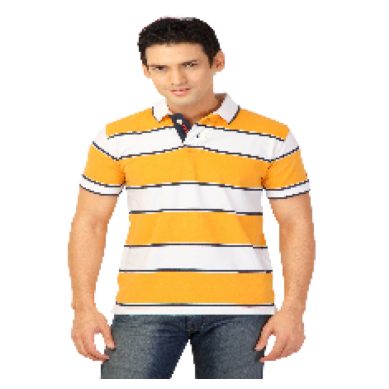

    _____________________________
    Релевантные товары


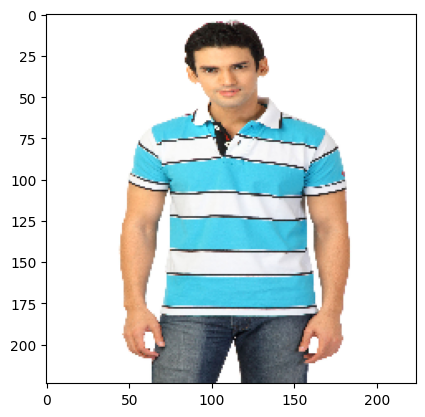

     Схожесть:  85.83 %


<ipython-input-24-3196ca20bdda>:18: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



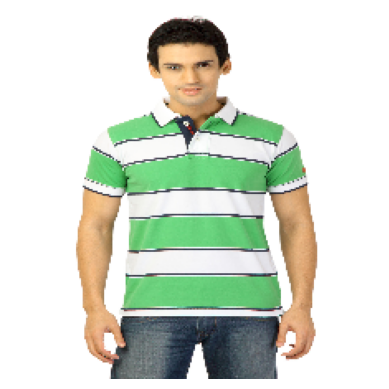

     Схожесть:  85.1 %


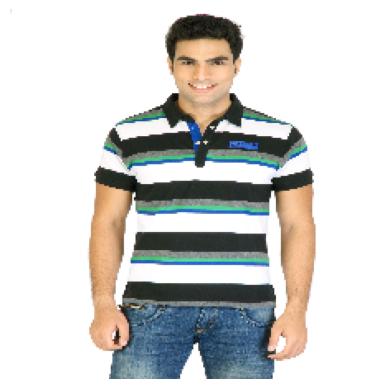

     Схожесть:  82.99 %


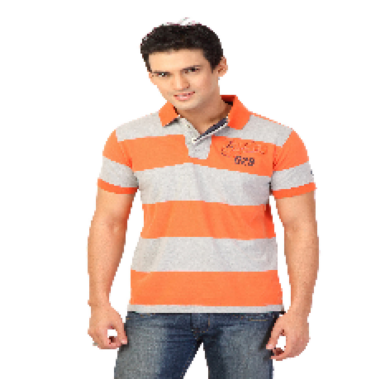

     Схожесть:  81.32 %


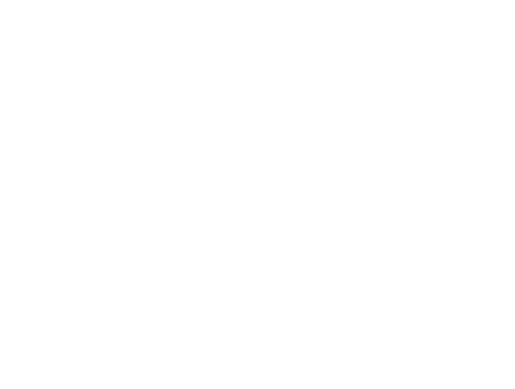

In [ ]:
retrieve_relevant_products(files[433])

     Выбранный товар


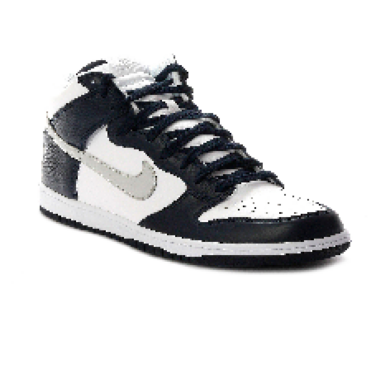

    _____________________________
    Релевантные товары


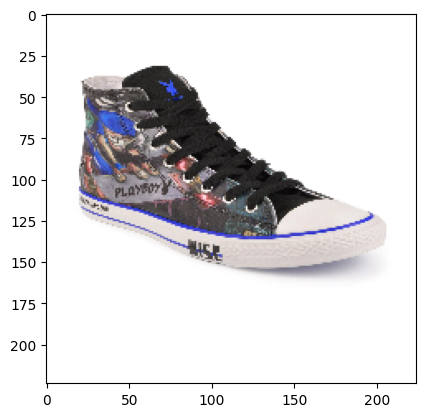

     Схожесть:  83.28 %


<ipython-input-24-3196ca20bdda>:18: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



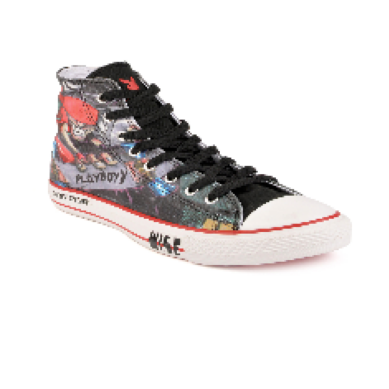

     Схожесть:  82.05 %


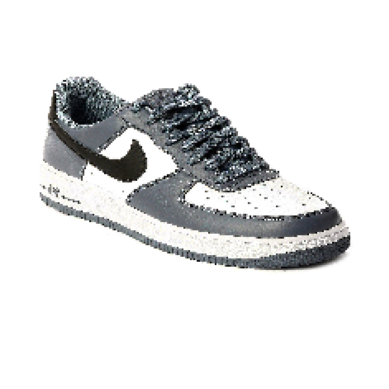

     Схожесть:  80.59 %


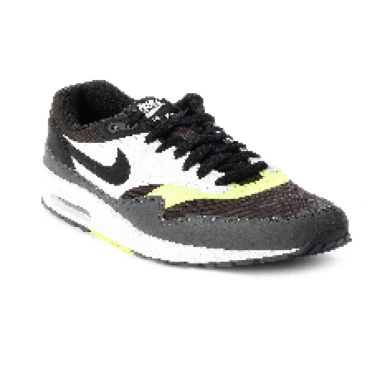

     Схожесть:  79.38 %


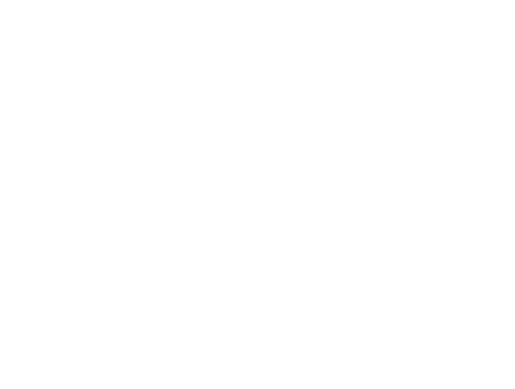

In [ ]:
retrieve_relevant_products(files[666])

С одной стороны, рекомендации одежды на моделях имеют более высокую точность: на предметах одежды без модели сложнее определить пол.

С другой, рекомендации одежды на моделях считают товар схожим, если схожи модели.

# Выбор лучшей модели

In [ ]:
import json
import time
from pathlib import Path
from datetime import datetime
import pickle
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.imagenet_utils import preprocess_input
import time
from collections import defaultdict
import seaborn as sns

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras.applications import VGG16, ResNet50, InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.imagenet_utils import preprocess_input

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras.applications import VGG16, ResNet50, InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.imagenet_utils import preprocess_input

In [ ]:
IMGS_PATH = "/content/drive/MyDrive/archive/fashion-dataset/fashion-dataset/images/"
IMG_SIZE = 224

def load_images(max_images=1000):
    files = [os.path.join(IMGS_PATH, f) for f in os.listdir(IMGS_PATH) if f.endswith('.jpg')][:max_images]
    images = []
    valid_files = []

    for f in files:
        try:
            img = load_img(f, target_size=(IMG_SIZE, IMG_SIZE))
            images.append(img)
            valid_files.append(f)
        except:
            continue

    return np.array(images), valid_files

images, filenames = load_images(max_images=1000)

In [ ]:
class FeatureExtractor:
    def __init__(self, model_name='vgg16'):
        if model_name == 'vgg16':
            base_model = VGG16(weights='imagenet')
            self.model = Model(inputs=base_model.input, outputs=base_model.get_layer('fc2').output)
        elif model_name == 'resnet50':
            base_model = ResNet50(weights='imagenet')
            self.model = Model(inputs=base_model.input, outputs=base_model.layers[-2].output)
        elif model_name == 'inceptionv3':
            base_model = InceptionV3(weights='imagenet')
            self.model = Model(inputs=base_model.input, outputs=base_model.layers[-2].output)

    def extract_features(self, images):
        processed_imgs = preprocess_input(np.array([img_to_array(img) for img in images]))
        return self.model.predict(processed_imgs)

Загружено 1000 изображений
32/32 ━━━━━━━━━━━━━━━━━━━━ 228s 7s/step

Анализ для изображения 433 (/content/drive/MyDrive/archive/fashion-dataset/fashion-dataset/images/12206.jpg):


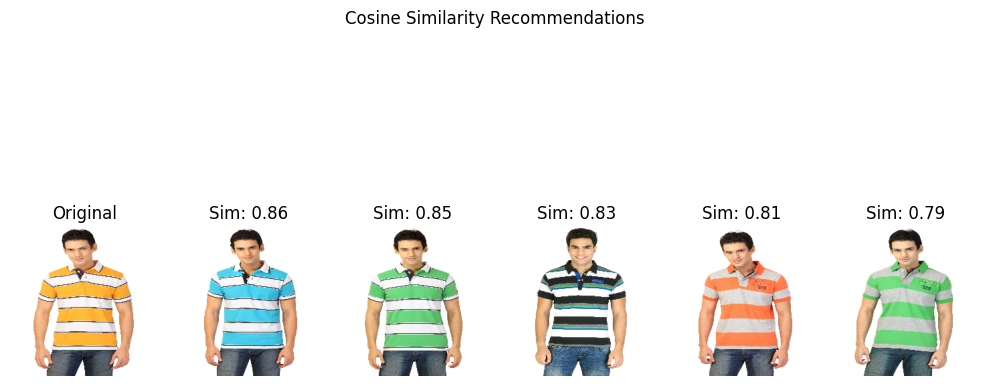

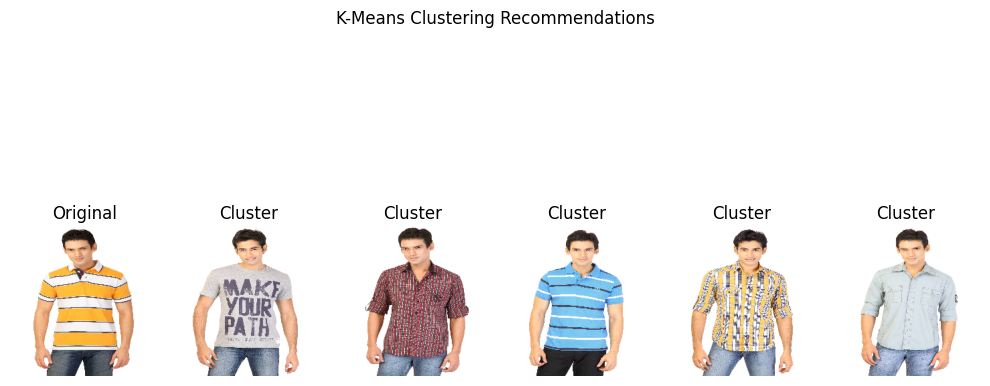

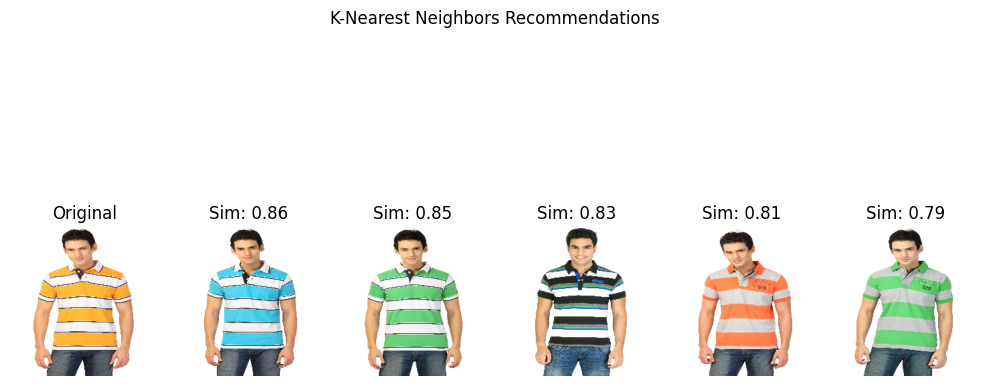


Метрики для текущего изображения:
Cosine: Similarity=0.828 Diversity=0.313 Time=0.014s
K-Means: Similarity=0.628 Diversity=0.408 Coverage=0.100 Time=0.619s
KNN: Similarity=0.828 Diversity=0.313 Time=0.017s

Анализ для изображения 666 (/content/drive/MyDrive/archive/fashion-dataset/fashion-dataset/images/17832.jpg):


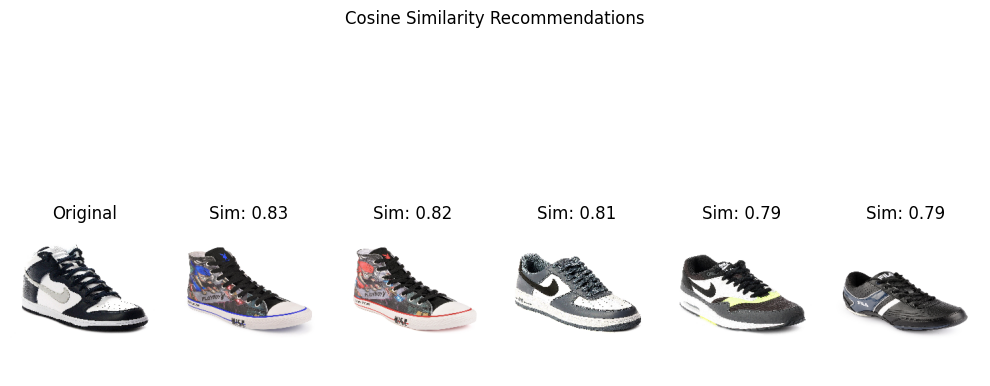

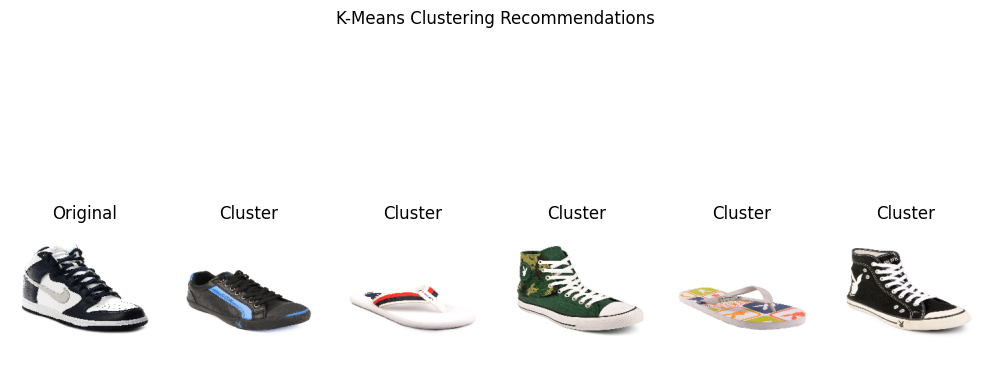

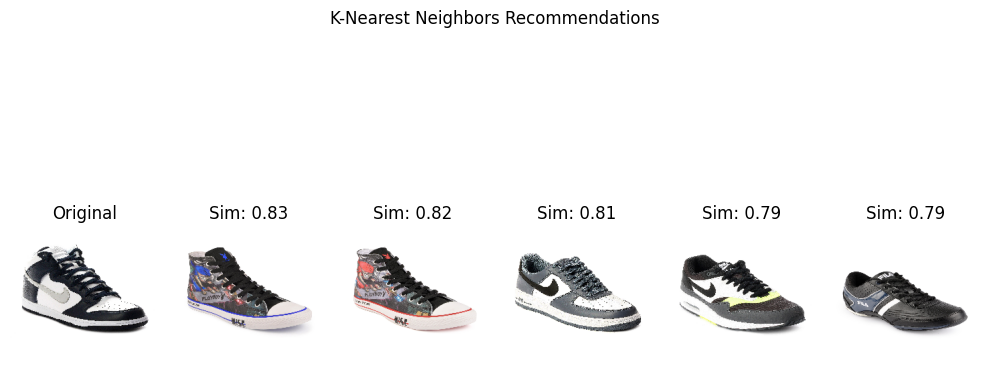


Метрики для текущего изображения:
Cosine: Similarity=0.809 Diversity=0.351 Time=0.014s
K-Means: Similarity=0.613 Diversity=0.520 Coverage=0.100 Time=0.656s
KNN: Similarity=0.809 Diversity=0.351 Time=0.017s

Анализ для изображения 101 (/content/drive/MyDrive/archive/fashion-dataset/fashion-dataset/images/11917.jpg):


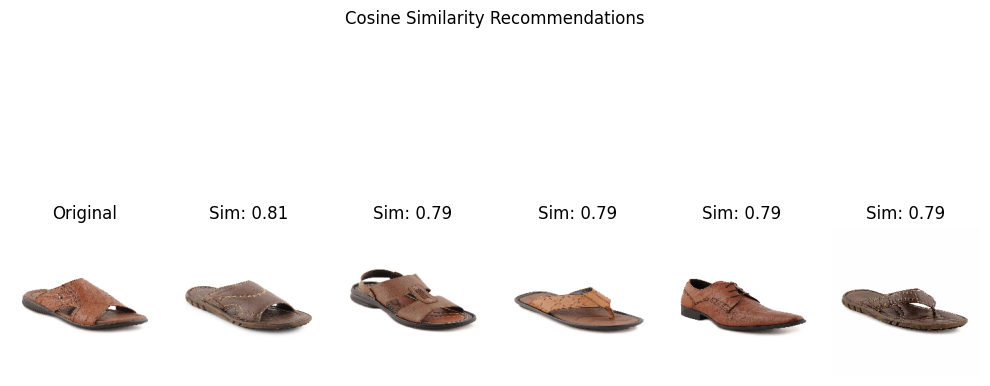

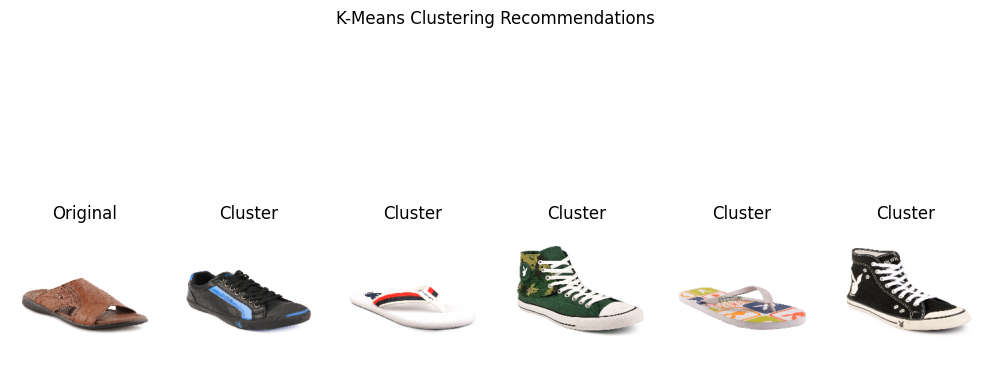

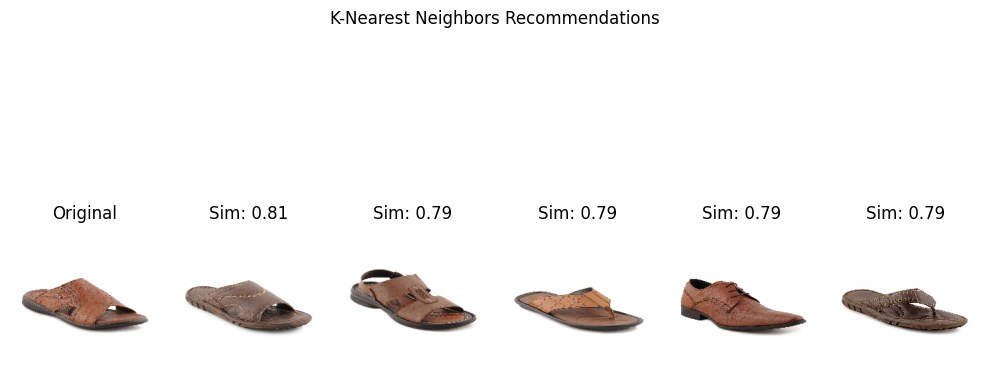


Метрики для текущего изображения:
Cosine: Similarity=0.792 Diversity=0.375 Time=0.014s
K-Means: Similarity=0.474 Diversity=0.520 Coverage=0.100 Time=0.628s
KNN: Similarity=0.792 Diversity=0.375 Time=0.017s

Итоговое сравнение методов:


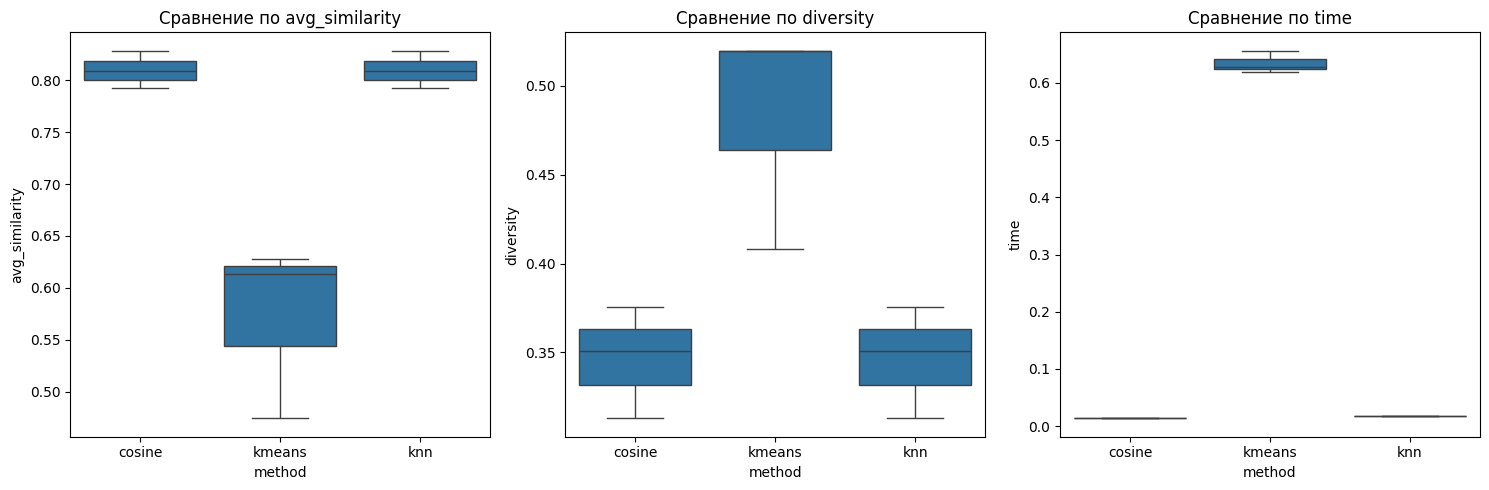


Анализ пересечений рекомендаций:

Изображение 433:
Общие рекомендации Cosine и K-Means: set()
Общие рекомендации Cosine и KNN: {np.int64(289), np.int64(419), np.int64(420), np.int64(345), np.int64(350)}
Общие рекомендации K-Means и KNN: set()
Рекомендации всеми тремя методами: set()

Изображение 666:
Общие рекомендации Cosine и K-Means: set()
Общие рекомендации Cosine и KNN: {np.int64(75), np.int64(111), np.int64(143), np.int64(665), np.int64(668)}
Общие рекомендации K-Means и KNN: set()
Рекомендации всеми тремя методами: set()

Изображение 101:
Общие рекомендации Cosine и K-Means: set()
Общие рекомендации Cosine и KNN: {np.int64(38), np.int64(198), np.int64(104), np.int64(136), np.int64(219)}
Общие рекомендации K-Means и KNN: set()
Рекомендации всеми тремя методами: set()

Среднее количество пересечений:
cos_kmeans    0.0
cos_knn       5.0
kmeans_knn    0.0
all_three     0.0
dtype: float64


In [ ]:
class RecommendationSystem:
    def __init__(self, features, filenames):
        self.features = features
        self.filenames = filenames
        self.n_images = len(filenames)
        self.metrics = {
            'cosine': defaultdict(dict),
            'kmeans': defaultdict(dict),
            'knn': defaultdict(dict)
        }
        self.timings = defaultdict(list)

    def _calculate_diversity(self, indices):
        """Вычисляет разнообразие рекомендаций (1 - средняя попарная схожесть)"""
        if len(indices) < 2:
            return 0
        similarities = cosine_similarity(self.features[indices])
        np.fill_diagonal(similarities, 0)
        return 1 - similarities.mean()

    def _calculate_coverage(self, indices, cluster_labels=None):
        """Вычисляет покрытие разных кластеров"""
        if cluster_labels is None:
            return 0
        unique_clusters = len(set(cluster_labels[indices]))
        total_clusters = len(set(cluster_labels))
        return unique_clusters / total_clusters

    def cosine_recommendations(self, img_idx, n_recommend=5):
        start_time = time.time()
        similarities = cosine_similarity([self.features[img_idx]], self.features)[0]
        top_indices = np.argsort(similarities)[::-1][1:n_recommend+1]

        self.metrics['cosine'][img_idx] = {
            'avg_similarity': np.mean(similarities[top_indices]),
            'diversity': self._calculate_diversity(top_indices),
            'time': time.time() - start_time
        }
        return top_indices, similarities[top_indices]

    def kmeans_recommendations(self, img_idx, n_clusters=10, n_recommend=5):
        start_time = time.time()
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        clusters = kmeans.fit_predict(self.features)
        img_cluster = clusters[img_idx]
        cluster_indices = np.where(clusters == img_cluster)[0]
        cluster_indices = cluster_indices[cluster_indices != img_idx][:n_recommend]

        self.metrics['kmeans'][img_idx] = {
            'avg_similarity': np.mean(cosine_similarity(
                [self.features[img_idx]],
                self.features[cluster_indices]
            )),
            'diversity': self._calculate_diversity(cluster_indices),
            'coverage': self._calculate_coverage(cluster_indices, clusters),
            'time': time.time() - start_time
        }
        return cluster_indices

    def knn_recommendations(self, img_idx, n_recommend=5):
        start_time = time.time()
        nn = NearestNeighbors(n_neighbors=n_recommend+1, metric='cosine')
        nn.fit(self.features)
        distances, indices = nn.kneighbors([self.features[img_idx]])
        indices = indices[0][1:]
        similarities = 1 - distances[0][1:]

        self.metrics['knn'][img_idx] = {
            'avg_similarity': np.mean(similarities),
            'diversity': self._calculate_diversity(indices),
            'time': time.time() - start_time
        }
        return indices, similarities

    def compare_methods(self):
        """Сравнивает методы по всем метрикам"""
        metrics_df = pd.DataFrame()

        for method in ['cosine', 'kmeans', 'knn']:
            for img_idx in self.metrics[method]:
                metrics_df = pd.concat([
                    metrics_df,
                    pd.DataFrame({
                        'method': [method],
                        'image_idx': [img_idx],
                        **self.metrics[method][img_idx]
                    })
                ], ignore_index=True)

        # Визуализация сравнения
        plt.figure(figsize=(15, 5))

        for i, metric in enumerate(['avg_similarity', 'diversity', 'time']):
            plt.subplot(1, 3, i+1)
            sns.boxplot(x='method', y=metric, data=metrics_df)
            plt.title(f'Сравнение по {metric}')

        plt.tight_layout()
        plt.show()

        return metrics_df

    def show_recommendations(self, img_idx, method='cosine', n_recommend=5):
        plt.figure(figsize=(10, 5))

        # Отображаем исходное изображение
        plt.subplot(1, n_recommend+1, 1)
        original = load_img(self.filenames[img_idx], target_size=(IMG_SIZE, IMG_SIZE))
        plt.imshow(original)
        plt.title("Original")
        plt.axis('off')

        # Получаем рекомендации
        if method == 'cosine':
            rec_indices, scores = self.cosine_recommendations(img_idx, n_recommend)
            title = "Cosine Similarity"
        elif method == 'kmeans':
            rec_indices = self.kmeans_recommendations(img_idx, n_recommend=n_recommend)
            scores = [1.0] * len(rec_indices)  # Для KMeans нет scores
            title = "K-Means Clustering"
        elif method == 'knn':
            rec_indices, scores = self.knn_recommendations(img_idx, n_recommend)
            title = "K-Nearest Neighbors"

        # Отображаем рекомендации
        for i, (idx, score) in enumerate(zip(rec_indices, scores)):
            plt.subplot(1, n_recommend+1, i+2)
            rec_img = load_img(self.filenames[idx], target_size=(IMG_SIZE, IMG_SIZE))
            plt.imshow(rec_img)
            plt.title(f"Sim: {score:.2f}" if method != 'kmeans' else f"Cluster")
            plt.axis('off')

        plt.suptitle(f"{title} Recommendations", y=1.05)
        plt.tight_layout()
        plt.show()

def main():
    images, filenames = load_images(max_images=1000)
    print(f"Загружено {len(images)} изображений")

    target_indices = [433, 666, 101]

    extractor = FeatureExtractor('vgg16')
    features = extractor.extract_features(images)

    rec_system = RecommendationSystem(features, filenames)

    for img_idx in target_indices:
        print(f"\nАнализ для изображения {img_idx} ({filenames[img_idx]}):")

        # Получаем рекомендации всеми методами
        cosine_idx, cosine_scores = rec_system.cosine_recommendations(img_idx)
        kmeans_idx = rec_system.kmeans_recommendations(img_idx)
        knn_idx, knn_scores = rec_system.knn_recommendations(img_idx)

        # Визуализация рекомендаций
        rec_system.show_recommendations(img_idx, method='cosine')
        rec_system.show_recommendations(img_idx, method='kmeans')
        rec_system.show_recommendations(img_idx, method='knn')

        print("\nМетрики для текущего изображения:")
        print_metrics(rec_system, img_idx)

    print("\nИтоговое сравнение методов:")
    metrics_df = rec_system.compare_methods()

    analyze_recommendation_overlaps(rec_system, target_indices)

def print_metrics(rec_system, img_idx):
    """Выводит метрики для конкретного изображения"""
    metrics = rec_system.metrics
    print(f"Cosine: Similarity={metrics['cosine'][img_idx]['avg_similarity']:.3f} "
          f"Diversity={metrics['cosine'][img_idx]['diversity']:.3f} "
          f"Time={metrics['cosine'][img_idx]['time']:.3f}s")

    print(f"K-Means: Similarity={metrics['kmeans'][img_idx]['avg_similarity']:.3f} "
          f"Diversity={metrics['kmeans'][img_idx]['diversity']:.3f} "
          f"Coverage={metrics['kmeans'][img_idx]['coverage']:.3f} "
          f"Time={metrics['kmeans'][img_idx]['time']:.3f}s")

    print(f"KNN: Similarity={metrics['knn'][img_idx]['avg_similarity']:.3f} "
          f"Diversity={metrics['knn'][img_idx]['diversity']:.3f} "
          f"Time={metrics['knn'][img_idx]['time']:.3f}s")

def analyze_recommendation_overlaps(rec_system, target_indices):
    """Анализирует пересечения между рекомендациями разных методов"""
    print("\nАнализ пересечений рекомендаций:")

    overlap_counts = []
    for img_idx in target_indices:
        cosine_idx, _ = rec_system.cosine_recommendations(img_idx)
        kmeans_idx = rec_system.kmeans_recommendations(img_idx)
        knn_idx, _ = rec_system.knn_recommendations(img_idx)

        cosine_set = set(cosine_idx)
        kmeans_set = set(kmeans_idx)
        knn_set = set(knn_idx)

        # Считаем пересечения
        cos_kmeans = cosine_set & kmeans_set
        cos_knn = cosine_set & knn_set
        kmeans_knn = kmeans_set & knn_set
        all_three = cosine_set & kmeans_set & knn_set

        overlap_counts.append({
            'cos_kmeans': len(cos_kmeans),
            'cos_knn': len(cos_knn),
            'kmeans_knn': len(kmeans_knn),
            'all_three': len(all_three)
        })

        print(f"\nИзображение {img_idx}:")
        print(f"Общие рекомендации Cosine и K-Means: {cos_kmeans}")
        print(f"Общие рекомендации Cosine и KNN: {cos_knn}")
        print(f"Общие рекомендации K-Means и KNN: {kmeans_knn}")
        print(f"Рекомендации всеми тремя методами: {all_three}")

    overlap_df = pd.DataFrame(overlap_counts)
    print("\nСреднее количество пересечений:")
    print(overlap_df.mean())

if __name__ == '__main__':
    main()

In [ ]:
IMGS_PATH = "/content/drive/MyDrive/archive/fashion-dataset/fashion-dataset/images/"
IMG_SIZE = 224

def load_images():
    files = [os.path.join(IMGS_PATH, f) for f in os.listdir(IMGS_PATH) if f.endswith('.jpg')]
    images = []
    valid_files = []

    for f in files:
        try:
            img = load_img(f, target_size=(IMG_SIZE, IMG_SIZE))
            images.append(img)
            valid_files.append(f)
        except:
            continue

    return np.array(images), valid_files

In [ ]:
images, filenames = load_images()
print(f"Загружено {len(images)} изображений")

extractor = FeatureExtractor('vgg16')
features = extractor.extract_features(images)

Загружено 2457 изображений
553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
77/77 ━━━━━━━━━━━━━━━━━━━━ 548s 7s/step


In [ ]:
np.save('features.npy', features)  # Матрица признаков
np.save('filenames.npy', filenames)  # Пути к изображениям

In [ ]:
features = np.load('/content/features (1).npy')
cosine_sim = np.load('/content/cosine_sim (1).npy')